<a href="https://colab.research.google.com/github/SergeiVKalinin/spm-reconstruction/blob/main/01_data_and_artifacts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Generation and Artifacts

This notebook shows how synthetic SPM images are created and what
the eight artifact types look like.

No reconstruction algorithms are used here — only the data generator.


In [1]:
# Setup — run once per Colab session
!git clone https://github.com/SergeiVKalinin/spm-reconstruction.git 2>/dev/null ||  (cd /content/spm-reconstruction && git pull)
import sys
sys.path.insert(0, '/content/spm-reconstruction')
print("Ready")

Ready


## 1. Generate one image

`make_scan()` is the single entry point. The same seed always
produces the same image.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from spm_data import make_scan

# Generate one image with all four original artifacts
data = make_scan(seed=42, Ny=128, Nx=128,
                 surface_type='sinusoidal',
                 artifacts=['crash', 'oscillation', 'drift'])

print(data)
print(f"forward shape : {data.forward.shape}")
print(f"true_surface  : {data.true_surface.shape}")
print(f"artifact_mask : {data.artifact_mask.shape}")
print(f"mask range    : [{data.artifact_mask.min():.2f}, "
      f"{data.artifact_mask.max():.2f}]")

ScanData(Ny=128, Nx=128, labelled, seed=42)
forward shape : (128, 128)
true_surface  : (128, 128)
artifact_mask : (128, 128)
mask range    : [0.00, 1.00]


## 2. Ground truth vs corrupted vs artifact mask

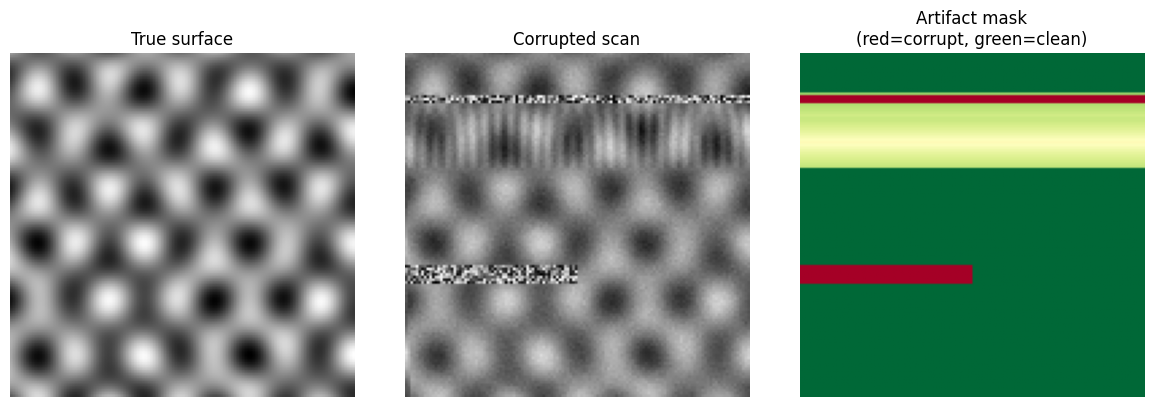

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(data.true_surface, cmap='gray', origin='upper')
axes[0].set_title('True surface')
axes[0].axis('off')

axes[1].imshow(data.forward, cmap='gray', origin='upper')
axes[1].set_title('Corrupted scan')
axes[1].axis('off')

axes[2].imshow(data.artifact_mask, cmap='RdYlGn_r',
               origin='upper', vmin=0, vmax=1)
axes[2].set_title('Artifact mask\n(red=corrupt, green=clean)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 3. All 8 artifact types

Each artifact type is applied independently to the same base surface.


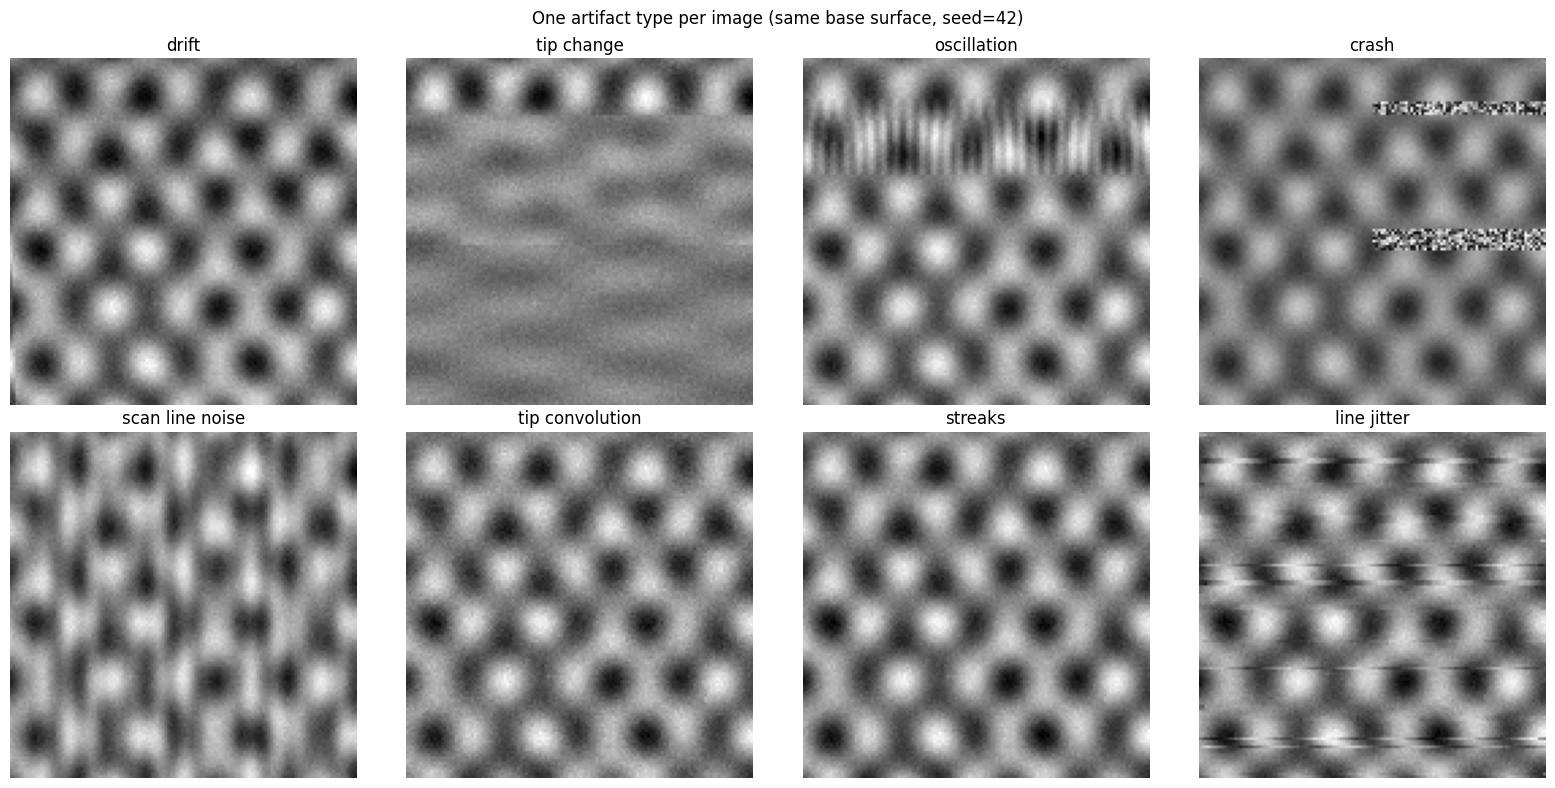

In [4]:
ARTIFACTS = [
    'drift', 'tip_change', 'oscillation', 'crash',
    'scan_line_noise', 'tip_convolution', 'streaks', 'line_jitter'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, art in enumerate(ARTIFACTS):
    d = make_scan(seed=42, Ny=128, Nx=128, artifacts=[art])
    axes[i].imshow(d.forward, cmap='gray', origin='upper')
    axes[i].set_title(art.replace('_', ' '))
    axes[i].axis('off')

plt.suptitle('One artifact type per image (same base surface, seed=42)')
plt.tight_layout()
plt.show()

## 4. The artifact mask for each type

The mask encodes how corrupted each pixel is:
- `0.0` = completely clean
- `1.0` = completely destroyed (crash)
- Between = partially corrupted


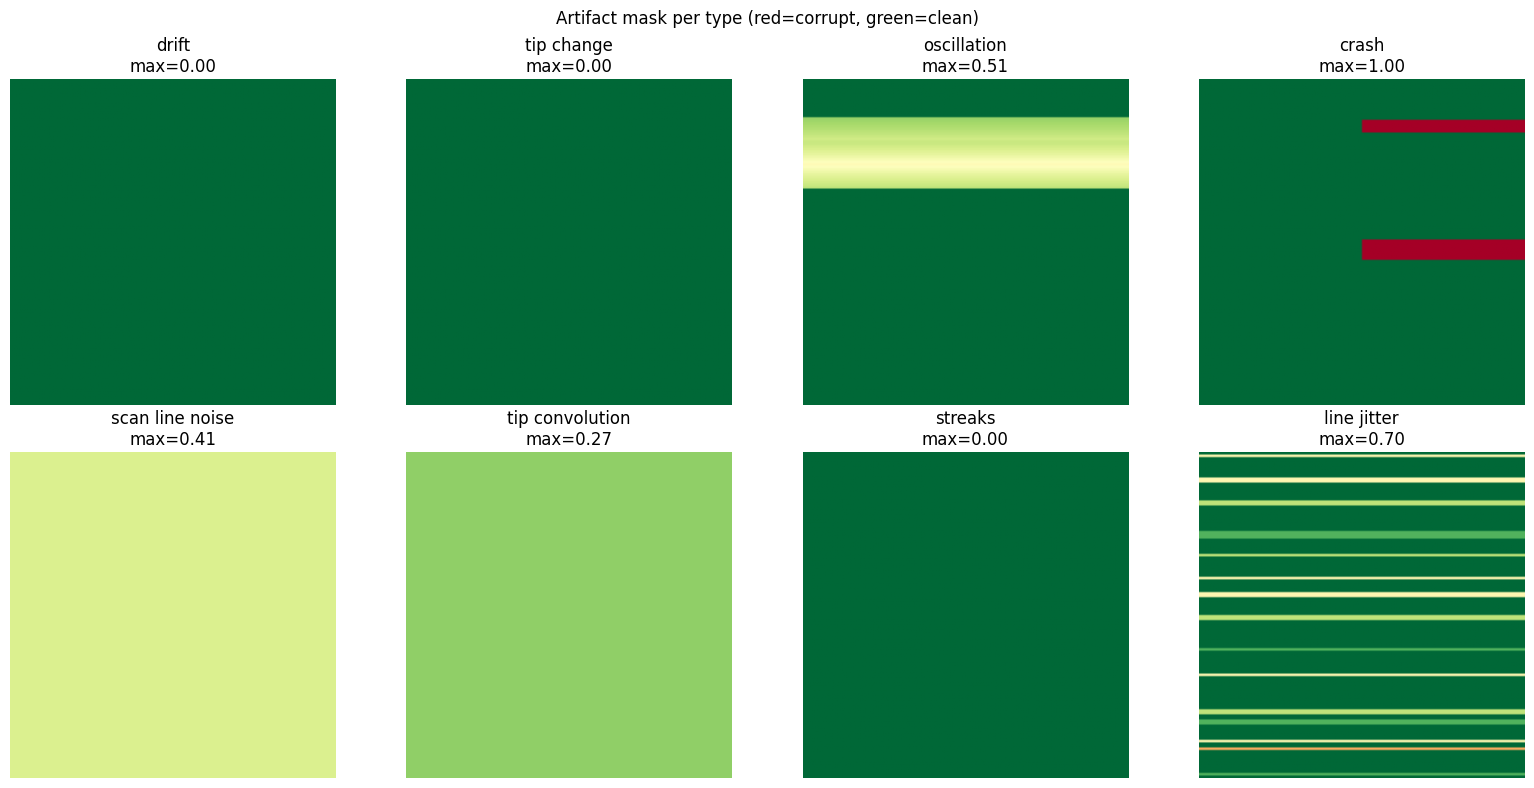

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, art in enumerate(ARTIFACTS):
    d = make_scan(seed=42, Ny=128, Nx=128, artifacts=[art])
    im = axes[i].imshow(d.artifact_mask, cmap='RdYlGn_r',
                        origin='upper', vmin=0, vmax=1)
    axes[i].set_title(f'{art.replace("_"," ")}\n'
                      f'max={d.artifact_mask.max():.2f}')
    axes[i].axis('off')

plt.suptitle('Artifact mask per type (red=corrupt, green=clean)')
plt.tight_layout()
plt.show()

## 5. The benchmark collection

`SPMCollection` provides reproducible benchmark images in three tiers.


SPMCollection(Tier0=8, Tier1=20, Tier2=12, default=64x64)

Tier 0: 8 unit test images
Tier 1: 20 standard benchmark images
Tier 2: 12 stress test images


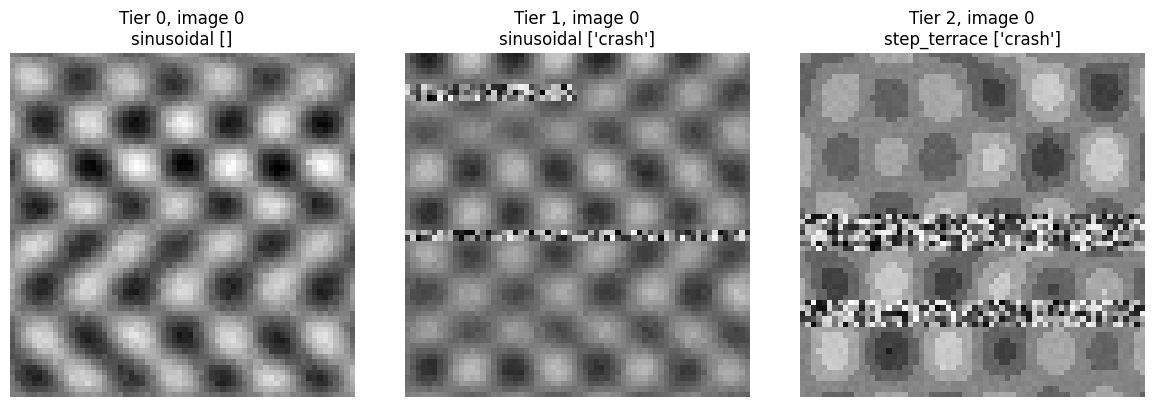

In [6]:
from spm_data import SPMCollection

col = SPMCollection(Ny=64, Nx=64)
print(col)
print(f"\nTier 0: {col.tier_size(0)} unit test images")
print(f"Tier 1: {col.tier_size(1)} standard benchmark images")
print(f"Tier 2: {col.tier_size(2)} stress test images")

# Show first image from each tier
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for tier in range(3):
    d = col.get(tier=tier, index=0)
    axes[tier].imshow(d.forward, cmap='gray', origin='upper')
    axes[tier].set_title(f'Tier {tier}, image 0\n'
                         f'{d.meta.get("surface_type","")} '
                         f'{d.meta.get("artifacts",[])}')
    axes[tier].axis('off')

plt.tight_layout()
plt.show()

## 6. Reproducibility check

The same seed always produces the same image.
Different seeds produce different images.


In [7]:
d1 = make_scan(seed=42)
d2 = make_scan(seed=42)
d3 = make_scan(seed=99)

print("Same seed, same image:",
      np.allclose(d1.forward, d2.forward))
print("Different seed, different image:",
      not np.allclose(d1.forward, d3.forward))

Same seed, same image: True
Different seed, different image: True
